In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Text Analytics/Project

/content/drive/MyDrive/Text Analytics/Project


In [ ]:
!pip install spacy scikit-learn genism


ERROR: Could not find a version that satisfies the requirement genism (from versions: none)
ERROR: No matching distribution found for genism


In [ ]:
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import pandas as pd
import spacy
from spacy.pipeline import EntityRuler
from spacy.tokens import Span
from spacy.language import Language
from spacy.symbols import PROPN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# For coherence and visualization
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

#### **1. Tokenize, lemmatization, remove stopwords**

In [ ]:
def build_nlp():
    nlp = spacy.load("en_core_web_sm")
    nlp.max_length = 4_000_000

    # 1) Mark protected terms before NER
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    patterns = [
        {"label": "PROTECTED_PROPN", "pattern": [{"LOWER": "elon"}, {"LOWER": "musk"}]},
        {"label": "PROTECTED_PROPN", "pattern": [{"LOWER": "tesla"}]},
        {"label": "PROTECTED_PROPN", "pattern": [{"LOWER": "spacex"}]},
    ]
    ruler.add_patterns(patterns)

    # 2) Register + add custom component
    @Language.component("merge_and_force_propn")
    def merge_and_force_propn(doc):
        spans = [ent for ent in doc.ents if ent.label_ == "PROTECTED_PROPN"]
        with doc.retokenize() as retok:
            for sp in spans:
                retok.merge(
                    sp,
                    attrs={"pos": PROPN, "tag": "NNP", "lemma": sp.text.lower(), "ent_type": sp.label}
                )
        for tok in doc:
            if tok.ent_type_ == "PROTECTED_PROPN":
                tok.pos = PROPN
                tok.tag_ = "NNP"
        return doc

    if "merge_and_force_propn" not in nlp.pipe_names:
        nlp.add_pipe("merge_and_force_propn", after="ner")

    return nlp

nlp = build_nlp()


In [ ]:
# -----------------------------------------
# 2) Stopwords (expand aggressively)
# -----------------------------------------
BASE_STOPS = set(nlp.Defaults.stop_words)
MORE_STOPS = {
    # generic filler / vague words
    "people","think","use","thing","want","time","work","life","world","way","good","new","year",
    "day","come","look","talk","right","like","make","find","need","get","say","take","know", "we",
    "i", "that", "lot", "m"
    # twitter/web artifacts
    "amp","rt"
}
STOPWORDS = BASE_STOPS | MORE_STOPS
# keep protected terms
for keep in ["elon", "musk", "elon musk", "tesla", "spacex"]:
    for part in keep.split():
        STOPWORDS.discard(part)
    STOPWORDS.discard(keep)

print(f"Number of stopwords: {len(STOPWORDS)}")

Number of stopwords: 351


In [ ]:
# ------------------------------------------------
# 3) Clean -> tokenize -> lemmatize -> stopwords
# ------------------------------------------------
def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "")).strip()

def to_tokens(text: str):
    """
    Returns a list of final tokens:
      - punctuation & spaces removed
      - protected terms merged and kept as single tokens: elon_musk, tesla, spacex
      - lowercased
      - lemmatized (except we keep lemma for words; for PROPN we use lower form)
      - stopwords removed
    """
    if not isinstance(text, str) or not text.strip():
        return []
    text = normalize_whitespace(text)
    if not text:
        return []

    doc = nlp(text)

    tokens = []
    for tok in doc:
        # Skip spaces/punctuation
        if tok.is_space or tok.is_punct:
            continue

        # Build raw lower form
        lower = tok.text.lower()

        # Collapse protected multi-word into underscored token
        # (after merging, protected is one token with ent_type_ set)
        if tok.ent_type_ == "PROTECTED_PROPN":
            if lower == "elon musk":
                norm = "elon_musk"
            else:
                norm = lower  # "tesla" or "spacex"
            tokens.append(norm)
            continue

        # Lemma (use lemma_ for normal words; for propn keep surface lower)
        if tok.pos_ == "PROPN":
            norm = lower
        else:
            lemma = tok.lemma_.lower()
            # Some lemmas are "-PRON-" or "" in small models; fallback to lower
            norm = lemma if lemma and lemma != "-pron-" else lower

        # Remove tokens that are stopwords or purely numeric or leftover punctuation
        if norm in STOPWORDS:
            continue
        if norm.isnumeric():
            continue
        if not re.search(r"[a-z0-9_]", norm):
            continue

        tokens.append(norm)

    return tokens
# Example usage
text = "  Elon Musk's Tesla cars are amazing! Visit https://tesla.com  "
print(to_tokens(text))

['elon_musk', 'tesla', 'car', 'amazing', 'visit', 'https://tesla.com']


In [ ]:
# ------------------
# 4) N-gram helpers
# ------------------
def make_ngrams(tokens, n=2):
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def token_pipeline(text: str, add_bigrams=True, add_trigrams=True):
    toks = to_tokens(text)
    if add_bigrams:
        toks += make_ngrams(toks, 2)
    if add_trigrams:
        toks += make_ngrams(toks, 3)
    return toks

# Example usage
text = "  Elon Musk's Tesla cars are like shit. Don't buy it anymore! Visit https://tesla.com  "
print(token_pipeline(text, add_bigrams=True, add_trigrams=True))


['elon_musk', 'tesla', 'car', 'shit', 'buy', 'anymore', 'visit', 'https://tesla.com', 'elon_musk_tesla', 'tesla_car', 'car_shit', 'shit_buy', 'buy_anymore', 'anymore_visit', 'visit_https://tesla.com', 'elon_musk_tesla_car', 'tesla_car_shit', 'car_shit_buy', 'shit_buy_anymore', 'buy_anymore_visit', 'anymore_visit_https://tesla.com', 'visit_https://tesla.com_elon_musk_tesla', 'https://tesla.com_elon_musk_tesla_tesla_car', 'elon_musk_tesla_tesla_car_car_shit', 'tesla_car_car_shit_shit_buy', 'car_shit_shit_buy_buy_anymore', 'shit_buy_buy_anymore_anymore_visit', 'buy_anymore_anymore_visit_visit_https://tesla.com']


In [ ]:
# ------------------------------------------
# 5) Apply to your DataFrame (example usage)
# ------------------------------------------
df = pd.read_csv("nbc_articles_with_content_official.csv")
df["tokens"] = df["content"].apply(lambda t: to_tokens(t))
df["tokens_with_ngrams"] = df["content"].apply(lambda t: token_pipeline(t))
df["clean_text"] = df["tokens"].apply(lambda ts: " ".join(ts))
df.to_csv("nbc_articles_cleaned.csv", index=False)


#### **2. Topic modelling - Article level** ####

In [ ]:
# 1) POS-filtered tokens: keep only PROPN & NOUN (Tesla, SpaceX, Autopilot, battery, etc.)
def to_tokens_nouns(text: str):
    if not isinstance(text, str) or not text.strip():
        return []
    doc = nlp(text)
    out = []
    for tok in doc:
        if tok.is_space or tok.is_punct or tok.like_url or tok.like_email:
            continue
        if tok.ent_type_ == "PROTECTED_PROPN":
            out.append(tok.lemma_.lower().replace(" ", "_"))
            continue
        if tok.pos_ not in {"PROPN", "NOUN"}:
            continue
        if tok.pos_ == "PROPN":
            norm = tok.text.lower()
        else:
            lemma = tok.lemma_.lower()
            norm = lemma if lemma and lemma != "-pron-" else tok.text.lower()
        if norm in STOPWORDS or norm.isnumeric() or not re.search(r"[a-z0-9_]", norm):
            continue
        out.append(norm)
    return out

In [ ]:
# 2) Build article-level text using only nouns/proper nouns
df = pd.read_csv("nbc_articles_cleaned.csv")
df["content"] = df["content"].fillna("").astype(str)  # use original content, not previously-cleaned string
df["tokens_nouns"] = df["content"].apply(to_tokens_nouns)
df["clean_text_nouns"] = df["tokens_nouns"].apply(lambda ts: " ".join(ts))
df = df[df["clean_text_nouns"].str.strip().ne("")].reset_index(drop=True)

# 3) Article-level LDA using only PROPN+NOUN
extra_stops = ["s","t","u","re","rt","amp","know","don"]
vect = CountVectorizer(
    stop_words=extra_stops,
    token_pattern=r"(?u)\b[a-z0-9_]+\b",
    lowercase=False,
    min_df=5,
    max_df=0.95
)
X = vect.fit_transform(df["clean_text_nouns"])

n_topics = 10
lda = LatentDirichletAllocation(
    n_components=n_topics, max_iter=20, learning_method="batch",
    random_state=42, n_jobs=-1
)
doc_topic = lda.fit_transform(X)
topic_term = lda.components_
terms = vect.get_feature_names_out()

def top_terms_for_topic(k, topn=10):
    idx = topic_term[k].argsort()[::-1][:topn]
    return ", ".join(terms[i] for i in idx)

topic_summary = pd.DataFrame({
    "topic": range(n_topics),
    "top_terms": [top_terms_for_topic(k) for k in range(n_topics)]
})

article_topic_df = pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(n_topics)])
for col in ["date","title","link"]:
    if col in df.columns: article_topic_df.insert(0, col, df[col].values)
article_topic_df["dominant_topic"] = article_topic_df.filter(like="topic_").idxmax(axis=1)
article_topic_df["dominant_score"] = article_topic_df.filter(like="topic_").max(axis=1)

topic_summary.to_csv("articles_topics_top_terms.csv", index=False)
article_topic_df.to_csv("article_topic_distribution.csv", index=False)
print("Saved article-level LDA using only PROPN+NOUN.")


Saved article-level LDA using only PROPN+NOUN.


# **LDA Testing with N topics**

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 10.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatibl

In [ ]:
# Assuming build_nlp() is defined and executed before this cell
try:
    nlp = nlp
except NameError:
    print("NLP model not found. Please run the cell that defines `build_nlp()` first.")
    # You might want to exit or raise an error here if nlp is essential

try:
    STOPWORDS = STOPWORDS
except NameError:
    print("STOPWORDS not found. Please run the cell that defines `STOPWORDS` first.")
    # You might want to exit or raise an error here if STOPWORDS is essential

# 1) Load and preprocess data (same as your code)
print("Loading and preprocessing data...")
df = pd.read_csv("nbc_articles_cleaned.csv")
df["content"] = df["content"].fillna("").astype(str)
df["tokens_nouns"] = df["content"].apply(to_tokens_nouns)
df["clean_text_nouns"] = df["tokens_nouns"].apply(lambda ts: " ".join(ts))
df = df[df["clean_text_nouns"].str.strip().ne("")].reset_index(drop=True)
print(f"Processed {len(df)} articles.")

# 2) Create the Document-Term Matrix (same as your code)
extra_stops = ["s","t","u","re","rt","amp","know","don", "people", "year", "time", "thing", "way"]
vect = CountVectorizer(
    stop_words=extra_stops,
    token_pattern=r"(?u)\b[a-z0-9_]+\b",
    lowercase=False,
    min_df=5,
    max_df=0.95
)
X = vect.fit_transform(df["clean_text_nouns"])
terms = vect.get_feature_names_out()

# --- NEW: Evaluation Workflow ---

# 3) Prepare inputs for Gensim's Coherence Model
# Gensim requires the tokenized text (list of lists of strings) and a dictionary
tokens_for_gensim = df["tokens_nouns"].tolist()
id2word = corpora.Dictionary(tokens_for_gensim)
# id2word.filter_extremes(no_below=5, no_above=0.95) # Optional filtering, similar to CountVectorizer

def calculate_topic_diversity(topic_terms):
    """Calculates topic diversity."""
    unique_words = set()
    total_words = 0
    for topic in topic_terms:
        unique_words.update(topic)
        total_words += len(topic)
    if total_words == 0:
        return 0
    return len(unique_words) / total_words

def evaluate_lda_models(X, min_topics, max_topics, step):
    """
    Train LDA models for a range of topics and compute evaluation metrics.
    """
    perplexity_scores = []
    coherence_scores_cv = []
    diversity_scores = []

    topic_range = range(min_topics, max_topics + 1, step)

    for k in topic_range:
        print(f"Training LDA model with {k} topics...")
        lda = LatentDirichletAllocation(
            n_components=k, max_iter=20, learning_method="batch",
            random_state=42, n_jobs=-1
        )
        lda.fit(X)

        # --- Calculate Perplexity ---
        perplexity = lda.perplexity(X)
        perplexity_scores.append(perplexity)

        # --- Calculate Coherence (C_v) ---
        # Get the top terms for each topic
        topic_terms = []
        for i in range(k):
            # Get top 10 terms for coherence calculation
            idx = lda.components_[i].argsort()[::-1][:10]
            topic_terms.append([terms[j] for j in idx])

        # Use Gensim to calculate coherence
        coherence_model = CoherenceModel(
            topics=topic_terms,
            texts=tokens_for_gensim,
            dictionary=id2word,
            coherence='c_v'
        )
        coherence_cv = coherence_model.get_coherence()
        coherence_scores_cv.append(coherence_cv)

        # --- Calculate Topic Diversity ---
        diversity = calculate_topic_diversity(topic_terms)
        diversity_scores.append(diversity)

        print(f"  Perplexity: {perplexity:.4f}")
        print(f"  Coherence (C_v): {coherence_cv:.4f}")
        print(f"  Diversity: {diversity:.4f}\n")

    return perplexity_scores, coherence_scores_cv, diversity_scores, topic_range

# Define the range of topics to test
MIN_TOPICS = 2
MAX_TOPICS = 16
STEP = 1

perplexity_scores, coherence_scores, diversity_scores, topic_range = evaluate_lda_models(
    X, MIN_TOPICS, MAX_TOPICS, STEP
)

Loading and preprocessing data...
Processed 5874 articles.
Training LDA model with 2 topics...
  Perplexity: 1955.4583
  Coherence (C_v): 0.5586
  Diversity: 0.9500

Training LDA model with 3 topics...
  Perplexity: 1748.7317
  Coherence (C_v): 0.7079
  Diversity: 0.9333

Training LDA model with 4 topics...
  Perplexity: 1663.4378
  Coherence (C_v): 0.7095
  Diversity: 0.9250

Training LDA model with 5 topics...
  Perplexity: 1558.6040
  Coherence (C_v): 0.6700
  Diversity: 0.9000

Training LDA model with 6 topics...
  Perplexity: 1517.0913
  Coherence (C_v): 0.6679
  Diversity: 0.8833

Training LDA model with 7 topics...
  Perplexity: 1487.6475
  Coherence (C_v): 0.6806
  Diversity: 0.8857

Training LDA model with 8 topics...
  Perplexity: 1458.9679
  Coherence (C_v): 0.6956
  Diversity: 0.8625

Training LDA model with 9 topics...
  Perplexity: 1443.0587
  Coherence (C_v): 0.7091
  Diversity: 0.8556

Training LDA model with 10 topics...
  Perplexity: 1423.7894
  Coherence (C_v): 0.688

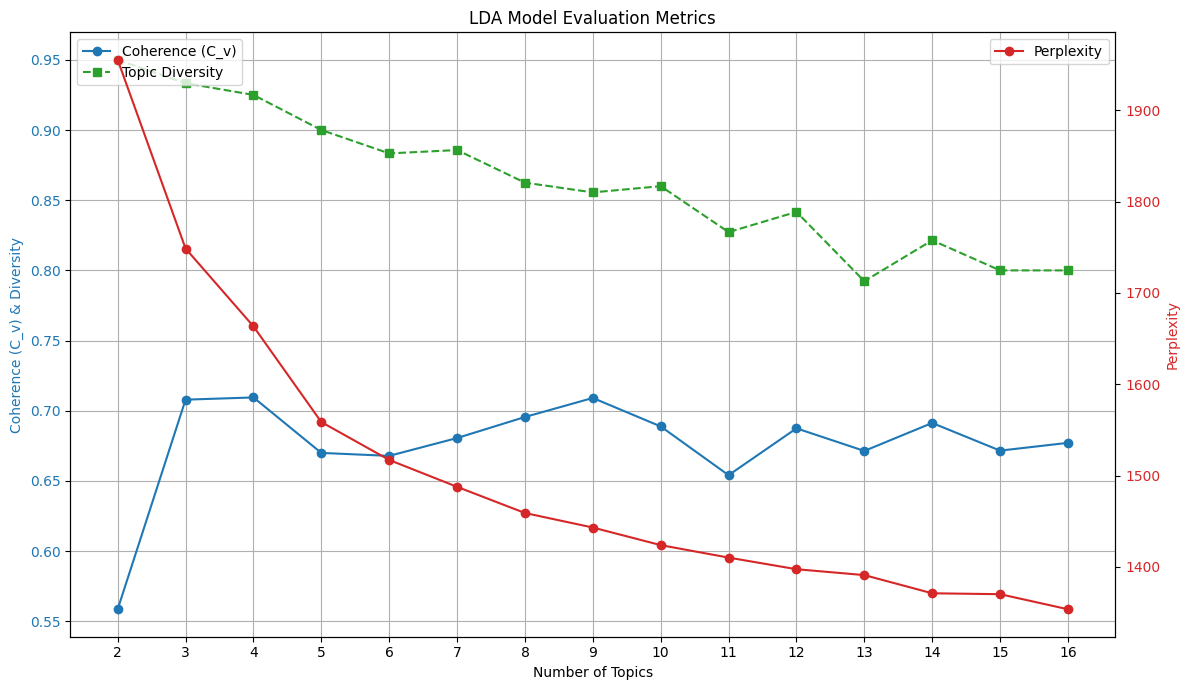

Saved evaluation metrics plot to 'lda_evaluation_metrics.png'


In [ ]:
# 4) Plot the results to find the optimal number of topics
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Coherence and Diversity
color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence (C_v) & Diversity', color=color)
ax1.plot(topic_range, coherence_scores, 'o-', color=color, label='Coherence (C_v)')
ax1.plot(topic_range, diversity_scores, 's--', color='tab:green', label='Topic Diversity')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax1.set_title('LDA Model Evaluation Metrics')
ax1.grid(True)

# Instantiate a second axes that shares the same x-axis for Perplexity
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)
ax2.plot(topic_range, perplexity_scores, 'o-', color=color, label='Perplexity')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()
plt.xticks(topic_range)
plt.show()

# Save the plot
fig.savefig("lda_evaluation_metrics.png", dpi=300)
print("Saved evaluation metrics plot to 'lda_evaluation_metrics.png'")



In [ ]:
OPTIMAL_N_TOPICS = 8 # <-- CHOOSE THIS BASED ON THE PLOT

print(f"\nTraining final LDA model with {OPTIMAL_N_TOPICS} topics...")
final_lda = LatentDirichletAllocation(
    n_components=OPTIMAL_N_TOPICS, max_iter=20, learning_method="batch",
    random_state=42, n_jobs=-1
)
doc_topic = final_lda.fit_transform(X)
topic_term = final_lda.components_

def top_terms_for_topic(k, topn=10):
    idx = topic_term[k].argsort()[::-1][:topn]
    return ", ".join(terms[i] for i in idx)

topic_summary = pd.DataFrame({
    "topic": range(OPTIMAL_N_TOPICS),
    "top_terms": [top_terms_for_topic(k) for k in range(OPTIMAL_N_TOPICS)]
})

article_topic_df = pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(OPTIMAL_N_TOPICS)])
for col in ["date","title","link"]:
    if col in df.columns: article_topic_df.insert(0, col, df[col].values)
article_topic_df["dominant_topic"] = article_topic_df.filter(like="topic_").idxmax(axis=1)
article_topic_df["dominant_score"] = article_topic_df.filter(like="topic_").max(axis=1)

topic_summary.to_csv("articles_topics_top_terms_final.csv", index=False)
article_topic_df.to_csv("article_topic_distribution_final.csv", index=False)
print("Saved final article-level LDA results.")


Training final LDA model with 6 topics...
Saved final article-level LDA results.
